# Week 11 Machine Learning Algorithms III
> by Lei Ding, Updated Apr. 2025

In [1]:
# 准备
#install.packages('neuralnet')
#install.packages('ggplotify')
#install.packages('caret')
#install.packages('kernlab')

## 1. 使用NN方法进行混凝土强度分类

In [2]:
##### Part 1: Neural Networks -------------------
## Example: Modeling the Strength of Concrete  ----

## Step 2: Exploring and preparing the data ----
# read in data and examine structure
concrete <- read.csv("concrete.csv")
str(concrete)

'data.frame':	1030 obs. of  9 variables:
 $ cement      : num  141 169 250 266 155 ...
 $ slag        : num  212 42.2 0 114 183.4 ...
 $ ash         : num  0 124.3 95.7 0 0 ...
 $ water       : num  204 158 187 228 193 ...
 $ superplastic: num  0 10.8 5.5 0 9.1 0 0 6.4 0 9 ...
 $ coarseagg   : num  972 1081 957 932 1047 ...
 $ fineagg     : num  748 796 861 670 697 ...
 $ age         : int  28 14 28 28 28 90 7 56 28 28 ...
 $ strength    : num  29.9 23.5 29.2 45.9 18.3 ...


In [3]:
# custom normalization function
normalize <- function(x) { 
  return((x - min(x)) / (max(x) - min(x)))
}

# apply normalization to entire data frame
concrete_norm <- as.data.frame(lapply(concrete, normalize))

# confirm that the range is now between zero and one
summary(concrete_norm$strength)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.2664  0.4001  0.4172  0.5457  1.0000 

In [4]:
# compared to the original minimum and maximum
summary(concrete$strength)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   2.33   23.71   34.45   35.82   46.13   82.60 

In [5]:
# create training and test data
concrete_train <- concrete_norm[1:773, ]
concrete_test <- concrete_norm[774:1030, ]

In [6]:
## Step 3: Training a model on the data ----
# train the neuralnet model
library(neuralnet)

# simple ANN with only a single hidden neuron
RNGversion("3.5.2") # use an older random number generator to match the book
set.seed(12345) # to guarantee repeatable results
concrete_model <- neuralnet(
    formula = strength ~ cement + slag + ash + water + superplastic + coarseagg + fineagg + age, 
    data = concrete_train)

Warning message in RNGkind("Mersenne-Twister", "Inversion", "Rounding"):
“non-uniform 'Rounding' sampler used”


Warning message in grid.echo.recordedplot(dl, newpage, prefix):
“No graphics to replay”


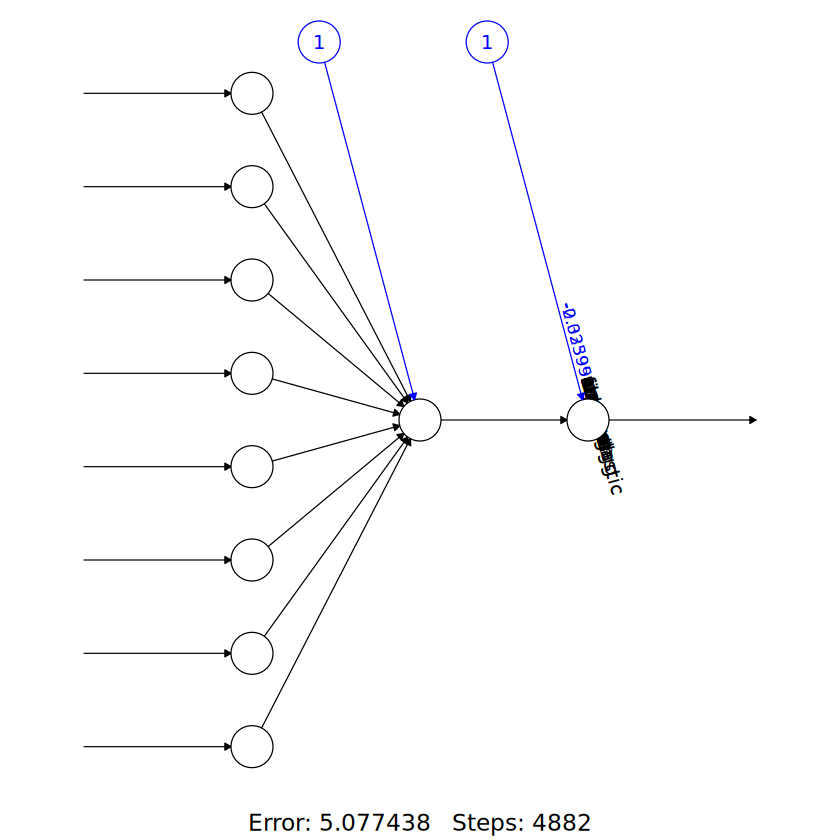

In [7]:
# visualize the network topology
#plot(concrete_model)

library(ggplotify)
as.ggplot(function() plot(concrete_model))

In [8]:
## Step 4: Evaluating model performance ----
# obtain model results
model_results <- compute(concrete_model, concrete_test[1:8])
# obtain predicted strength values
predicted_strength <- model_results$net.result
# examine the correlation between predicted and actual values
cor(predicted_strength, concrete_test$strength)

0.8064656


Warning message in RNGkind("Mersenne-Twister", "Inversion", "Rounding"):
“non-uniform 'Rounding' sampler used”
Warning message in grid.echo.recordedplot(dl, newpage, prefix):
“No graphics to replay”


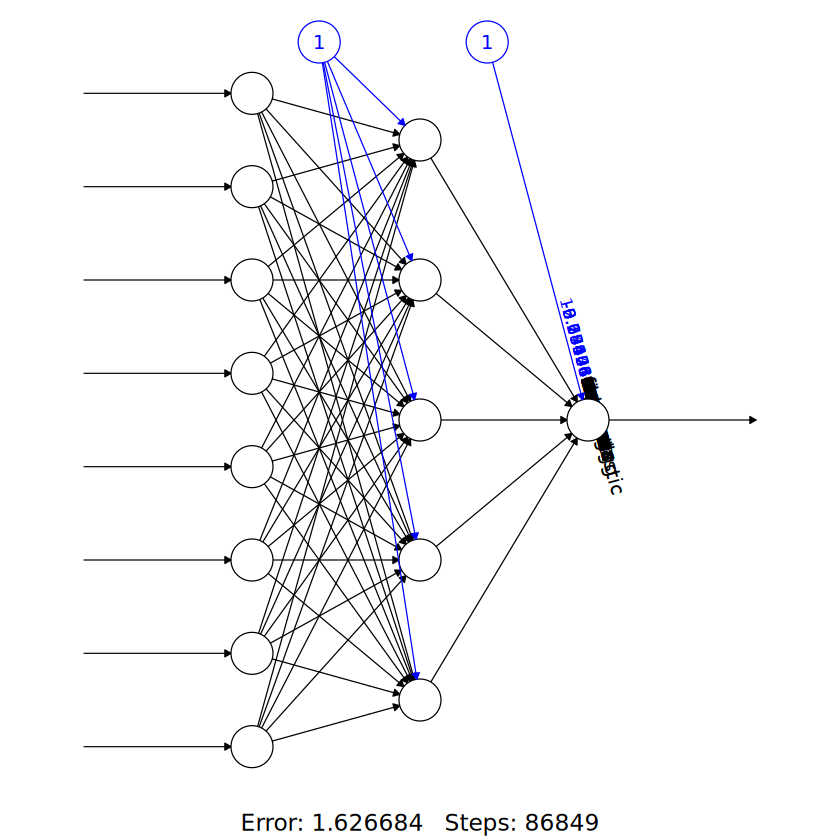

In [9]:
## Step 5: Improving model performance ----
# a more complex neural network topology with 5 hidden neurons
RNGversion("3.5.2") # use an older random number generator to match the book
set.seed(12345) # to guarantee repeatable results
concrete_model2 <- neuralnet(
    strength ~ cement + slag + ash + water + superplastic + coarseagg + fineagg + age,
    data = concrete_train, hidden = 5)

# plot the network
#plot(concrete_model2)
as.ggplot(function() plot(concrete_model2))

In [10]:
# evaluate the results as we did before
model_results2 <- compute(concrete_model2, concrete_test[1:8])
predicted_strength2 <- model_results2$net.result
cor(predicted_strength2, concrete_test$strength)

0.9244533


Warning message in RNGkind("Mersenne-Twister", "Inversion", "Rounding"):
“non-uniform 'Rounding' sampler used”
Warning message in grid.echo.recordedplot(dl, newpage, prefix):
“No graphics to replay”


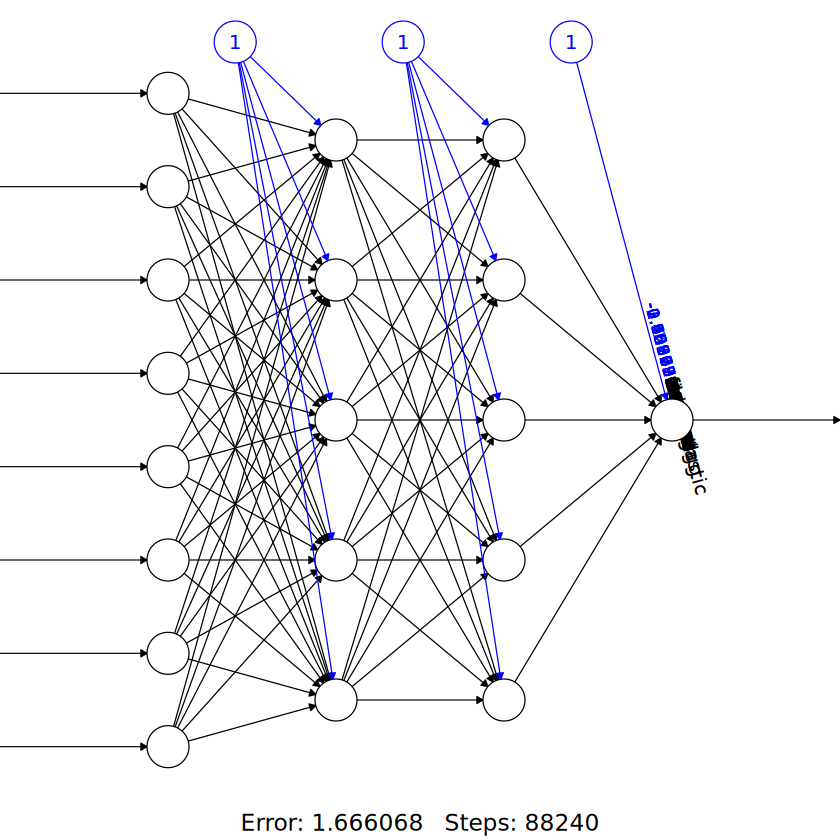

In [11]:
# an EVEN MORE complex neural network topology with two hidden layers and custom activation function

# create a custom softplus activation function
softplus <- function(x) { log(1 + exp(x)) }

RNGversion("3.5.2") # use an older random number generator to match the book
set.seed(12345) # to guarantee repeatable results
concrete_model3 <- neuralnet(
    strength ~ cement + slag + ash + water + superplastic + coarseagg + fineagg + age,
    data = concrete_train, hidden = c(5, 5), act.fct = softplus)

# plot the network
#plot(concrete_model3)
as.ggplot(function() plot(concrete_model3))

In [12]:
# evaluate the results as we did before
model_results3 <- compute(concrete_model3, concrete_test[1:8])
predicted_strength3 <- model_results3$net.result
cor(predicted_strength3, concrete_test$strength)

0.9348395


In [13]:
# note that the predicted and actual values are on different scales
strengths <- data.frame(actual = concrete$strength[774:1030], pred = predicted_strength3)
head(strengths, n = 3)

,actual,pred
,<dbl>,<dbl>
774,30.14,0.2860639
775,44.40,0.4777305
776,24.50,0.2840964


In [14]:
# this doesn't change the correlations (but would affect absolute error)
cor(strengths$pred, strengths$actual)

[1] 0.9348395

In [15]:
# create an unnormalize function to reverse the normalization
unnormalize <- function(x) {
  return((x * (max(concrete$strength)) - min(concrete$strength)) + min(concrete$strength))
}

strengths$pred_new <- unnormalize(strengths$pred)
strengths$error <- strengths$pred_new - strengths$actual

head(strengths, n = 3)

,actual,pred,pred_new,error
,<dbl>,<dbl>,<dbl>,<dbl>
774,30.14,0.2860639,23.62888,-6.511121
775,44.40,0.4777305,39.46054,-4.939464
776,24.50,0.2840964,23.46636,-1.033635


In [16]:
cor(strengths$pred_new, strengths$actual)

[1] 0.9348395

Warning message in grid.echo.recordedplot(dl, newpage, prefix):
“No graphics to replay”


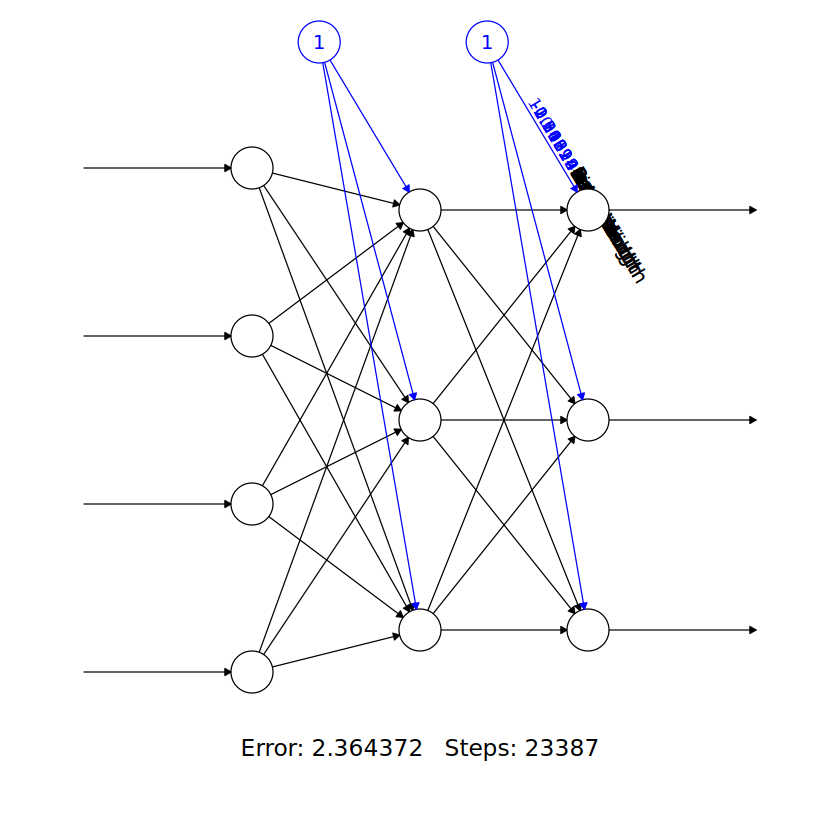

In [17]:
#iris数据集
data("iris")
ind <- sample(2, nrow(iris), replace=TRUE, prob=c(0.7, 0.3))
trainset <- iris[ind==1, ]
testset <- iris[ind==2, ]
trainset$setosa <- trainset$Species == "setosa"
trainset$virginica <- trainset$Species == "virginica"
trainset$versicolor <- trainset$Species == "versicolor"
library(neuralnet)

attach(iris)
network <- neuralnet(
    versicolor + virginica + setosa ~ Sepal.Length + Sepal.Width + Petal.Length + Petal.Width, 
    trainset, hidden = 3)

#plot(network)
as.ggplot(function() plot(network))

In [18]:
net.predict <- compute(network, testset[-5])$net.result
net.predict

1,-0.0015890471,0.009474185,0.992152066
2,-0.0027789669,0.010127771,0.992674426
5,-0.0012726091,0.009217625,0.992092730
7,-0.0044533891,0.012047926,0.992443517
9,-0.0084768067,0.015723487,0.992790819
11,-0.0006227778,0.008626597,0.992033260
14,-0.0034006780,0.011096106,0.992342103
15,0.0017741532,0.006487113,0.991773697
16,0.0006939941,0.007514037,0.991829706
17,-0.0006960660,0.008708064,0.992025630
18,-0.0027116218,0.010462303,0.992286642


In [19]:
net.prediction <- c("versicolor", "virginica", "setosa")[apply(net.predict, 1, which.max)]
table(testset$Species, net.prediction)

            net.prediction
             setosa versicolor virginica
  setosa         20          0         0
  versicolor      0         17         1
  virginica       0          0        15

In [20]:
caret::confusionMatrix(testset$Species, factor(net.prediction))

Confusion Matrix and Statistics

            Reference
Prediction   setosa versicolor virginica
  setosa         20          0         0
  versicolor      0         17         1
  virginica       0          0        15

Overall Statistics
                                          
               Accuracy : 0.9811          
                 95% CI : (0.8993, 0.9995)
    No Information Rate : 0.3774          
    P-Value [Acc > NIR] : < 2.2e-16       
                                          
                  Kappa : 0.9716          
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: setosa Class: versicolor Class: virginica
Sensitivity                 1.0000            1.0000           0.9375
Specificity                 1.0000            0.9722           1.0000
Pos Pred Value              1.0000            0.9444           1.0000
Neg Pred Value              1.0000            1.0000           0.9737
P

## 2. 使用SVM进行光学字符识别

In [21]:
##### Part 2: Support Vector Machines -------------------
## Example: Optical Character Recognition ----

## Step 2: Exploring and preparing the data ----
# read in data and examine structure
letters <- read.csv("letterdata.csv", stringsAsFactors = TRUE)
str(letters)

'data.frame':	20000 obs. of  17 variables:
 $ letter: Factor w/ 26 levels "A","B","C","D",..: 20 9 4 14 7 19 2 1 10 13 ...
 $ xbox  : int  2 5 4 7 2 4 4 1 2 11 ...
 $ ybox  : int  8 12 11 11 1 11 2 1 2 15 ...
 $ width : int  3 3 6 6 3 5 5 3 4 13 ...
 $ height: int  5 7 8 6 1 8 4 2 4 9 ...
 $ onpix : int  1 2 6 3 1 3 4 1 2 7 ...
 $ xbar  : int  8 10 10 5 8 8 8 8 10 13 ...
 $ ybar  : int  13 5 6 9 6 8 7 2 6 2 ...
 $ x2bar : int  0 5 2 4 6 6 6 2 2 6 ...
 $ y2bar : int  6 4 6 6 6 9 6 2 6 2 ...
 $ xybar : int  6 13 10 4 6 5 7 8 12 12 ...
 $ x2ybar: int  10 3 3 4 5 6 6 2 4 1 ...
 $ xy2bar: int  8 9 7 10 9 6 6 8 8 9 ...
 $ xedge : int  0 2 3 6 1 0 2 1 1 8 ...
 $ xedgey: int  8 8 7 10 7 8 8 6 6 1 ...
 $ yedge : int  0 4 3 2 5 9 7 2 1 1 ...
 $ yedgex: int  8 10 9 8 10 7 10 7 7 8 ...


In [22]:
# divide into training and test data
letters_train <- letters[1:16000, ]
letters_test  <- letters[16001:20000, ]

In [23]:
## Step 3: Training a model on the data ----
# begin by training a simple linear SVM
library(kernlab)
letter_classifier <- ksvm(letter ~ ., data = letters_train, kernel = "vanilladot")

# look at basic information about the model
letter_classifier

 Setting default kernel parameters  


Support Vector Machine object of class "ksvm" 

SV type: C-svc  (classification) 
 parameter : cost C = 1 

Linear (vanilla) kernel function. 

Number of Support Vectors : 7037 

Objective Function Value : -14.1746 -20.0072 -23.5628 -6.2009 -7.5524 -32.7694 -49.9786 -18.1824 -62.1111 -32.7284 -16.2209 -32.2837 -28.9777 -51.2195 -13.276 -35.6217 -30.8612 -16.5256 -14.6811 -32.7475 -30.3219 -7.7956 -11.8138 -32.3463 -13.1262 -9.2692 -153.1654 -52.9678 -76.7744 -119.2067 -165.4437 -54.6237 -41.9809 -67.2688 -25.1959 -27.6371 -26.4102 -35.5583 -41.2597 -122.164 -187.9178 -222.0856 -21.4765 -10.3752 -56.3684 -12.2277 -49.4899 -9.3372 -19.2092 -11.1776 -100.2186 -29.1397 -238.0516 -77.1985 -8.3339 -4.5308 -139.8534 -80.8854 -20.3642 -13.0245 -82.5151 -14.5032 -26.7509 -18.5713 -23.9511 -27.3034 -53.2731 -11.4773 -5.12 -13.9504 -4.4982 -3.5755 -8.4914 -40.9716 -49.8182 -190.0269 -43.8594 -44.8667 -45.2596 -13.5561 -17.7664 -87.4105 -107.1056 -37.0245 -30.7133 -112.3218 -32.9619 -27.2971 -35.5

In [24]:
## Step 4: Evaluating model performance ----
# predictions on testing dataset
letter_predictions <- predict(letter_classifier, letters_test)

head(letter_predictions)

[1] U N V X N H
Levels: A B C D E F G H I J K L M N O P Q R S T U V W X Y Z

In [25]:
table(letter_predictions, letters_test$letter)

                  
letter_predictions   A   B   C   D   E   F   G   H   I   J   K   L   M   N   O
                 A 144   0   0   0   0   0   0   0   0   1   0   0   1   2   2
                 B   0 121   0   5   2   0   1   2   0   0   1   0   1   0   0
                 C   0   0 120   0   4   0  10   2   2   0   1   3   0   0   2
                 D   2   2   0 156   0   1   3  10   4   3   4   3   0   5   5
                 E   0   0   5   0 127   3   1   1   0   0   3   4   0   0   0
                 F   0   0   0   0   0 138   2   2   6   0   0   0   0   0   0
                 G   1   1   2   1   9   2 123   2   0   0   1   2   1   0   1
                 H   0   0   0   1   0   1   0 102   0   2   3   2   3   4  20
                 I   0   1   0   0   0   1   0   0 141   8   0   0   0   0   0
                 J   0   1   0   0   0   1   0   2   5 128   0   0   0   0   1
                 K   1   1   9   0   0   0   2   5   0   0 118   0   0   2   0
                 L   0   0   0   

In [26]:
# look only at agreement vs. non-agreement
# construct a vector of TRUE/FALSE indicating correct/incorrect predictions
agreement <- letter_predictions == letters_test$letter
table(agreement)

agreement
FALSE  TRUE 
  643  3357 

In [27]:
prop.table(table(agreement))

agreement
  FALSE    TRUE 
0.16075 0.83925 

In [28]:
## Step 5: Improving model performance ----

# change to a RBF kernel
RNGversion("3.5.2") # use an older random number generator to match the book
set.seed(12345)
letter_classifier_rbf <- ksvm(letter ~ ., data = letters_train, kernel = "rbfdot")
letter_predictions_rbf <- predict(letter_classifier_rbf, letters_test)

agreement_rbf <- letter_predictions_rbf == letters_test$letter
table(agreement_rbf)

Warning message in RNGkind("Mersenne-Twister", "Inversion", "Rounding"):
“non-uniform 'Rounding' sampler used”


agreement_rbf
FALSE  TRUE 
  275  3725 

In [29]:
prop.table(table(agreement_rbf))

agreement_rbf
  FALSE    TRUE 
0.06875 0.93125 

Warning message in RNGkind("Mersenne-Twister", "Inversion", "Rounding"):
“non-uniform 'Rounding' sampler used”


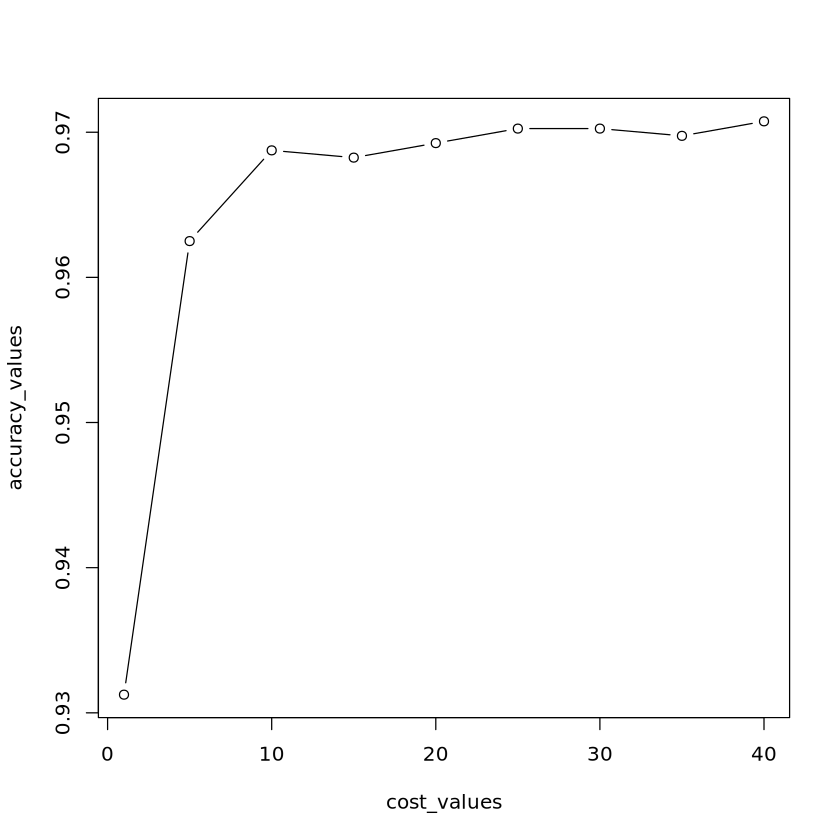

In [30]:
# test various values of the cost parameter
cost_values <- c(1, seq(from = 5, to = 40, by = 5))

RNGversion("3.5.2") # use an older random number generator to match the book
accuracy_values <- sapply(cost_values, function(x) {
  set.seed(12345)
  m <- ksvm(letter ~ ., data = letters_train, kernel = "rbfdot", C = x)
  pred <- predict(m, letters_test)
  agree <- ifelse(pred == letters_test$letter, 1, 0)
  accuracy <- sum(agree) / nrow(letters_test)
  return (accuracy)
})

plot(cost_values, accuracy_values, type = "b")

## 3. 用k均值方法探寻青少年市场细分

In [31]:
##### Part 3: Clustering with k-means -------------------

## Example: Finding Teen Market Segments ----
## Step 2: Exploring and preparing the data ----
teens <- read.csv("snsdata.csv", stringsAsFactors = TRUE)
str(teens)

'data.frame':	30000 obs. of  40 variables:
 $ gradyear    : int  2006 2006 2006 2006 2006 2006 2006 2006 2006 2006 ...
 $ gender      : Factor w/ 2 levels "F","M": 2 1 2 1 NA 1 1 2 1 1 ...
 $ age         : num  19 18.8 18.3 18.9 19 ...
 $ friends     : int  7 0 69 0 10 142 72 17 52 39 ...
 $ basketball  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ football    : int  0 1 1 0 0 0 0 0 0 0 ...
 $ soccer      : int  0 0 0 0 0 0 0 0 0 0 ...
 $ softball    : int  0 0 0 0 0 0 0 1 0 0 ...
 $ volleyball  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ swimming    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ cheerleading: int  0 0 0 0 0 0 0 0 0 0 ...
 $ baseball    : int  0 0 0 0 0 0 0 0 0 0 ...
 $ tennis      : int  0 0 0 0 0 0 0 0 0 0 ...
 $ sports      : int  0 0 0 0 0 0 0 0 0 0 ...
 $ cute        : int  0 1 0 1 0 0 0 0 0 1 ...
 $ sex         : int  0 0 0 0 1 1 0 2 0 0 ...
 $ sexy        : int  0 0 0 0 0 0 0 1 0 0 ...
 $ hot         : int  0 0 0 0 0 0 0 0 0 1 ...
 $ kissed      : int  0 0 0 0 5 0 0 0 0 0 ...
 $ dance       : int

In [32]:
# look at missing data for female variable
table(teens$gender)


    F     M 
22054  5222 

In [33]:
table(teens$gender, useNA = "ifany")


    F     M  <NA> 
22054  5222  2724 

In [34]:
# look at missing data for age variable
summary(teens$age)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  3.086  16.312  17.287  17.994  18.259 106.927    5086 

In [35]:
# eliminate age outliers
teens$age <- ifelse(teens$age >= 13 & teens$age < 20, teens$age, NA)
summary(teens$age)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  13.03   16.30   17.27   17.25   18.22   20.00    5523 

In [36]:
# reassign missing gender values to "unknown"
teens$female <- ifelse(teens$gender == "F" & !is.na(teens$gender), 1, 0)
teens$no_gender <- ifelse(is.na(teens$gender), 1, 0)

# check our recoding work
table(teens$gender, useNA = "ifany")


    F     M  <NA> 
22054  5222  2724 

In [37]:
table(teens$female, useNA = "ifany")


    0     1 
 7946 22054 

In [38]:
table(teens$no_gender, useNA = "ifany")


    0     1 
27276  2724 

In [39]:
# finding the mean age by cohort
mean(teens$age) # doesn't work
mean(teens$age, na.rm = TRUE) # works

[1] NA

[1] 17.25243

In [40]:
# age by cohort
aggregate(data = teens, age ~ gradyear, mean, na.rm = TRUE)

gradyear,age
<int>,<dbl>
2006,18.65586
2007,17.70617
2008,16.76770
2009,15.81957


In [41]:
# create a vector with the average age for each gradyear, repeated by person
ave_age <- ave(teens$age, teens$gradyear, FUN = function(x) mean(x, na.rm = TRUE))

teens$age <- ifelse(is.na(teens$age), ave_age, teens$age)

# check the summary results to ensure missing values are eliminated
summary(teens$age)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  13.03   16.28   17.24   17.24   18.21   20.00 

In [42]:
## Step 3: Training a model on the data ----

# create a z-score standardized data frame for easier interpretation
interests <- teens[5:40]
interests_z <- as.data.frame(lapply(interests, scale))

# compare the data before and after the transformation
summary(interests$basketball)
summary(interests_z$basketball)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.0000  0.0000  0.0000  0.2673  0.0000 24.0000 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-0.3322 -0.3322 -0.3322  0.0000 -0.3322 29.4923 

In [43]:
# create the clusters using k-means
RNGversion("3.5.2") # use an older random number generator to match the book
set.seed(2345)
teen_clusters <- kmeans(interests_z, 5)

## Step 4: Evaluating model performance ----
# look at the size of the clusters
teen_clusters$size

Warning message in RNGkind("Mersenne-Twister", "Inversion", "Rounding"):
“non-uniform 'Rounding' sampler used”


[1]   871   600  5981  1034 21514

In [44]:
# look at the cluster centers
teen_clusters$centers

,basketball,football,soccer,softball,volleyball,swimming,cheerleading,baseball,tennis,sports,⋯,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
1,0.16001227,0.2364174,0.10385512,0.07232021,0.18897158,0.23970234,0.3931445,0.02993479,0.13532387,0.10257837,⋯,0.06137340,0.60368108,0.79806891,0.5651537331,4.1521844,3.96493810,0.043475966,0.09857501,0.035614771,0.03443294
2,-0.09195886,0.0652625,-0.09932124,-0.01739428,-0.06219308,0.03339844,-0.1101103,-0.11487510,0.04062204,-0.09899231,⋯,-0.01146396,-0.08724304,-0.03865318,-0.0003526292,-0.1678300,-0.14129577,0.009447317,0.05135888,-0.086773220,-0.06878491
3,0.52755083,0.4873480,0.29778605,0.37178877,0.37986175,0.29628671,0.3303485,0.35231971,0.14057808,0.32967130,⋯,0.03471458,0.48318495,0.66327838,0.3759725120,-0.0553846,-0.07417839,0.037989066,0.11972190,-0.009688746,-0.05973769
4,0.34081039,0.3593965,0.12722250,0.16384661,0.11032200,0.26943332,0.1856664,0.27527088,0.10980958,0.79711920,⋯,0.36134138,0.62256686,0.27101815,1.2306917174,0.1610784,0.26324494,1.712181870,0.93631312,1.897388200,2.73326605
5,-0.16695523,-0.1641499,-0.09033520,-0.11367669,-0.11682181,-0.10595448,-0.1136077,-0.10918483,-0.05097057,-0.13135334,⋯,-0.02918252,-0.18625656,-0.22865236,-0.1865419798,-0.1557662,-0.14861104,-0.094875180,-0.08370729,-0.087520105,-0.11423381


In [45]:
## Step 5: Improving model performance ----
# apply the cluster IDs to the original data frame
teens$cluster <- teen_clusters$cluster

# look at the first five records
teens[1:5, c("cluster", "gender", "age", "friends")]

,cluster,gender,age,friends
,<int>,<fct>,<dbl>,<int>
1,5,M,18.982,7
2,3,F,18.801,0
3,5,M,18.335,69
4,5,F,18.875,0
5,4,NA,18.995,10


In [46]:
# mean age by cluster
aggregate(data = teens, age ~ cluster, mean)

cluster,age
<int>,<dbl>
1,16.86497
2,17.39037
3,17.07656
4,17.11957
5,17.29849


In [47]:
# proportion of females by cluster
aggregate(data = teens, female ~ cluster, mean)

cluster,female
<int>,<dbl>
1,0.8381171
2,0.7250000
3,0.8378198
4,0.8027079
5,0.6994515


In [48]:
# mean number of friends by cluster
aggregate(data = teens, friends ~ cluster, mean)

cluster,friends
<int>,<dbl>
1,41.43054
2,32.57333
3,37.16185
4,30.50290
5,27.70052
